# Gateway Placement Optimization — cleaned pipeline

Loads the already-fitted path-loss + GPR pipelines for **both RSSI and SNR**
and finds gateway positions that reliably cover the greenhouse.

**Reliable coverage** = RSSI > −105 dBm AND SNR > −3 dB, both required at once.

## Method

**Primary — GPR-informed ellipse placement (continuous, "place anywhere"):**
1. Compute a conservative *GPR residual margin* over the greenhouse — a low
   quantile of `residual_mean − z·residual_std` from the fitted GPR. This is
   what the GPR knows about local signal dips, condensed into one number per
   metric.
2. Fold that margin into the coverage thresholds and solve the along-row (x)
   and cross-row (y) threshold radii separately (row crossings scale with
   |dy|, so the footprint is anisotropic). Intersect the RSSI and SNR
   footprints exactly and fit an area-matched, aspect-matched ellipse.
3. Because the ellipse only depends on the *relative* offset from the gateway
   (path loss is translation-invariant; the GPR enters via the margin, not a
   position-dependent bump), it can be placed anywhere. Greedy set cover over
   a dense candidate grid picks the placement.
4. **Validate the final placement against the real two-stage GPR model** —
   the ellipse is a candidate generator, never the final answer.

**Fallback — discrete multi-restart greedy:** for when teammates provide a
fixed list of real, feasible mounting positions. Ranks candidates by
standalone coverage against the full GPR model and greedily selects, with
multi-restart to catch the greedy-first-pick-suboptimal failure mode.
Disabled by default (`RUN_FALLBACK = False`).

## Required artifacts (same directory, or set `MODEL_DIR`)
- `coord_scaler_full_dataset.pkl`
- `gpr_hetero_final_candidate.pkl`, `pathloss_coeffs_full_dataset.pkl` (RSSI)
- `gpr_hetero_snr_final_candidate.pkl`, `pathloss_coeffs_snr_full_dataset.pkl` (SNR)


## 0. Configuration

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.patches import Ellipse

# --- coverage definition ------------------------------------------------
RSSI_THRESHOLD_DBM = -105
SNR_THRESHOLD_DB = -3

# Uncertainty margin: a point only counts as covered if (mean - z*std)
# clears the threshold. z=1.645 -> one-sided ~95% confidence.
# Used both in the GPR residual margin (primary method) and in the
# full-model validation / fallback.
Z_MARGIN = 1.645

# Quantile of (residual_mean - z*residual_std) over the greenhouse used as
# the conservative GPR margin for the ellipse footprint. 0.10 = "size the
# ellipse so it holds even in the worst ~10% of GPR-predicted locations".
RESIDUAL_QUANTILE = 0.10

# --- greenhouse geometry ------------------------------------------------
X_MIN, X_MAX = -162.0, 162.0    # along rows
Y_MIN, Y_MAX = -138.6, 305.25   # across rows
ROW_SPACING = 1.65
CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX = -2.0, 2.0  # excluded corridor

# --- grid resolutions ---------------------------------------------------
EVAL_RESOLUTION = 1.0      # full-resolution grid (reference only; slow)
REPORT_RESOLUTION = 2.5    # final validation + report figures
SEARCH_RESOLUTION = 5.0    # coarse grid for the placement search

# --- primary method settings --------------------------------------------
CANDIDATE_SPACING_M = 15.0   # dense candidate grid ("place anywhere")
MAX_GATEWAYS = 8
MIN_MARGINAL_GAIN = 1e-6     # greedy stop threshold (fraction of area)
FOOTPRINT_GRID_RES_M = 1.0   # resolution of the exact-footprint mask

# --- fallback (discrete candidates from teammates) -----------------------
RUN_FALLBACK = False
# When enabled, define real_candidates_df with columns
# ['candidate_id', 'x', 'y'] before the fallback section.

MODEL_DIR = "."  # adjust to wherever the .pkl files live


## 1. Load model artifacts

In [2]:
# Coordinate scaler is shared: both RSSI and SNR GPR were fitted on the
# same scaled greenhouse coordinates.
coord_scaler = joblib.load(f"{MODEL_DIR}/coord_scaler_full_dataset.pkl")

rssi_gpr_model = joblib.load(f"{MODEL_DIR}/gpr_hetero_final_candidate.pkl")
rssi_pathloss_coeffs = joblib.load(f"{MODEL_DIR}/pathloss_coeffs_full_dataset.pkl")

snr_gpr_model = joblib.load(f"{MODEL_DIR}/gpr_hetero_snr_final_candidate.pkl")
snr_pathloss_coeffs = joblib.load(f"{MODEL_DIR}/pathloss_coeffs_snr_full_dataset.pkl")

print('RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]:', rssi_pathloss_coeffs)
print('SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]:', snr_pathloss_coeffs)


RSSI pathloss coeffs [intercept, log10_slope, crossing_slope]: [-27.01746878 -35.3566277   -0.03728326]
SNR  pathloss coeffs [intercept, log10_slope, crossing_slope]: [ 26.17845621 -10.18096175  -0.10043079]


## 2. Evaluation grids

In [3]:
def make_evaluation_grid(x_min, x_max, y_min, y_max, resolution,
                         exclude_x_range=None):
    xs = np.arange(x_min, x_max + resolution, resolution)
    ys = np.arange(y_min, y_max + resolution, resolution)
    xx, yy = np.meshgrid(xs, ys)
    grid_df = pd.DataFrame({"x": xx.ravel(), "y": yy.ravel()})
    if exclude_x_range is not None:
        low, high = exclude_x_range
        grid_df = grid_df[~grid_df["x"].between(low, high)].reset_index(drop=True)
    return grid_df


_exclude = (CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX)
report_grid = make_evaluation_grid(X_MIN, X_MAX, Y_MIN, Y_MAX, REPORT_RESOLUTION, _exclude)
search_grid = make_evaluation_grid(X_MIN, X_MAX, Y_MIN, Y_MAX, SEARCH_RESOLUTION, _exclude)

print(f"report_grid: {len(report_grid)} points ({REPORT_RESOLUTION} m)")
print(f"search_grid: {len(search_grid)} points ({SEARCH_RESOLUTION} m)")


report_grid: 23091 points (2.5 m)
search_grid: 5850 points (5.0 m)


## 3. Shared prediction machinery

Full two-stage prediction (deterministic path loss + fixed-in-space GPR
residual correction) at every grid point, for any candidate gateway
position. This is the *real model* — the primary method's ellipse is only
ever a candidate generator, and everything is validated against these
functions at the end.

In [4]:
def compute_distance_and_crossings(points_df, gw_x, gw_y, row_spacing=ROW_SPACING):
    dx = points_df["x"].values - gw_x
    dy = points_df["y"].values - gw_y
    distance = np.sqrt(dx**2 + dy**2)
    row_crossings = np.round(np.abs(dy) / row_spacing).astype(int)
    return distance, row_crossings


def pathloss_prediction(distance, row_crossings, coeffs):
    """coeffs = [intercept, log10_slope, crossing_slope] as saved in
    pathloss_coeffs_*_full_dataset.pkl."""
    intercept, log10_slope, crossing_slope = coeffs
    return (intercept
            + log10_slope * np.log10(np.maximum(distance, 1e-3))
            + crossing_slope * row_crossings)


def predict_signal_for_gateway(gw_x, gw_y, grid_df, gpr_model, pathloss_coeffs):
    """Two-stage prediction (path loss + GPR residual) for ONE target.
    Note: gpr_model.predict(return_std=True) is already in original units
    (do NOT rescale — normalize_y handles it internally for predict)."""
    distance, row_crossings = compute_distance_and_crossings(grid_df, gw_x, gw_y)
    pl_pred = pathloss_prediction(distance, row_crossings, pathloss_coeffs)

    coords_scaled = coord_scaler.transform(grid_df[["x", "y"]].values)
    residual_mean, residual_std = gpr_model.predict(coords_scaled, return_std=True)

    return pl_pred + residual_mean, residual_std


def predict_rssi_snr_for_gateway(gw_x, gw_y, grid_df):
    rssi_mean, rssi_std = predict_signal_for_gateway(
        gw_x, gw_y, grid_df, rssi_gpr_model, rssi_pathloss_coeffs)
    snr_mean, snr_std = predict_signal_for_gateway(
        gw_x, gw_y, grid_df, snr_gpr_model, snr_pathloss_coeffs)
    return rssi_mean, rssi_std, snr_mean, snr_std


def coverage_mask(rssi_mean, rssi_std, snr_mean, snr_std,
                  rssi_threshold=RSSI_THRESHOLD_DBM,
                  snr_threshold=SNR_THRESHOLD_DB, z=Z_MARGIN):
    """A point is 'reliably covered' only if BOTH lower confidence bounds
    (mean - z*std) clear their thresholds."""
    rssi_ok = (rssi_mean - z * rssi_std) > rssi_threshold
    snr_ok = (snr_mean - z * snr_std) > snr_threshold
    return rssi_ok & snr_ok


def compute_coverage_assignment(selected, candidates_df, grid_df, cache=None,
                                rssi_threshold=RSSI_THRESHOLD_DBM,
                                snr_threshold=SNR_THRESHOLD_DB, z=Z_MARGIN):
    """For a finalized list of selected candidate_ids: which gateway
    'best-serves' each grid point (highest RSSI mean among selected — the
    gateway a device would actually attach to) and whether coverage holds
    there. SNR travels with the RSSI winner; the two are never mixed from
    different gateways at the same point."""
    if cache is None:
        cache = {}
    for cand_id in selected:
        if cand_id not in cache:
            row = candidates_df.loc[candidates_df["candidate_id"] == cand_id].iloc[0]
            cache[cand_id] = predict_rssi_snr_for_gateway(row["x"], row["y"], grid_df)

    n_points = len(grid_df)
    best_rssi_mean = np.full(n_points, -np.inf)
    best_rssi_std = np.zeros(n_points)
    best_snr_mean = np.full(n_points, -np.inf)
    best_snr_std = np.zeros(n_points)
    serving_idx = np.full(n_points, -1)

    for i, cand_id in enumerate(selected):
        rssi_mean, rssi_std, snr_mean, snr_std = cache[cand_id]
        switch = rssi_mean > best_rssi_mean
        best_rssi_mean = np.where(switch, rssi_mean, best_rssi_mean)
        best_rssi_std = np.where(switch, rssi_std, best_rssi_std)
        best_snr_mean = np.where(switch, snr_mean, best_snr_mean)
        best_snr_std = np.where(switch, snr_std, best_snr_std)
        serving_idx = np.where(switch, i, serving_idx)

    covered = coverage_mask(best_rssi_mean, best_rssi_std,
                            best_snr_mean, best_snr_std,
                            rssi_threshold, snr_threshold, z=z)
    return serving_idx, covered


def plot_gateway_coverage(selected, candidates_df, grid_df, cache=None,
                          rssi_threshold=RSSI_THRESHOLD_DBM,
                          snr_threshold=SNR_THRESHOLD_DB, z=Z_MARGIN,
                          title="Gateway Placement & Coverage"):
    """Grid points colored by serving gateway; solid = reliably covered,
    faded = in that gateway's zone but below threshold."""
    serving_idx, covered = compute_coverage_assignment(
        selected, candidates_df, grid_df, cache=cache,
        rssi_threshold=rssi_threshold, snr_threshold=snr_threshold, z=z)

    fig, ax = plt.subplots(figsize=(12, 9))
    cmap = plt.get_cmap("tab10")

    for i, cand_id in enumerate(selected):
        color = cmap(i % 10)
        zone = serving_idx == i
        ax.scatter(grid_df.loc[zone & covered, "x"], grid_df.loc[zone & covered, "y"],
                   s=6, color=color, alpha=0.7, rasterized=True,
                   label=f"Gateway {cand_id}")
        ax.scatter(grid_df.loc[zone & ~covered, "x"], grid_df.loc[zone & ~covered, "y"],
                   s=6, color=color, alpha=0.10, rasterized=True)

    for i, cand_id in enumerate(selected):
        row = candidates_df.loc[candidates_df["candidate_id"] == cand_id].iloc[0]
        ax.scatter(row["x"], row["y"], marker="^", s=260, color=cmap(i % 10),
                   edgecolor="black", linewidth=1.5, zorder=5)
        ax.annotate(str(cand_id), (row["x"], row["y"]), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontweight="bold", fontsize=10)

    total_coverage = covered.mean()
    ax.set_title(
        f"{title}\n{len(selected)} gateway(s) — {total_coverage:.1%} of area reliably covered "
        f"(RSSI > {rssi_threshold} dBm AND SNR > {snr_threshold} dB, z={z})\n"
        f"faded points = in that gateway's zone but below threshold")
    ax.set_xlabel("X (m, along row / path)")
    ax.set_ylabel("Y (m, across rows)")
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8, markerscale=3)
    plt.tight_layout()
    return fig, ax


## 4. PRIMARY — GPR-informed ellipse footprint

### 4.1 GPR residual margin

The GPR residual surface is fixed in greenhouse coordinates (it was fitted
against measurements from one gateway position), so it can't be baked into a
translation-invariant footprint directly. What *can* be: a conservative
summary of it. Coverage requires

`pathloss(dx, dy) + residual(x, y) − z·std(x, y) > threshold`,

so requiring `pathloss > threshold − r_low`, where `r_low` is a low quantile
of `residual_mean − z·residual_std` over the whole greenhouse, guarantees the
full-model condition except in the worst `RESIDUAL_QUANTILE` fraction of
GPR-predicted locations. That adjusted threshold is what the ellipse is
solved against — the GPR enters the footprint, but the footprint stays the
same shape everywhere.

In [5]:
# Predict GPR residuals once over the greenhouse (gateway-independent).
_search_coords_scaled = coord_scaler.transform(search_grid[["x", "y"]].values)

rssi_res_mean, rssi_res_std = rssi_gpr_model.predict(_search_coords_scaled, return_std=True)
snr_res_mean, snr_res_std = snr_gpr_model.predict(_search_coords_scaled, return_std=True)

rssi_r_low = np.quantile(rssi_res_mean - Z_MARGIN * rssi_res_std, RESIDUAL_QUANTILE)
snr_r_low = np.quantile(snr_res_mean - Z_MARGIN * snr_res_std, RESIDUAL_QUANTILE)

# Effective thresholds the deterministic path loss must clear on its own
RSSI_EFF_THRESHOLD = RSSI_THRESHOLD_DBM - rssi_r_low
SNR_EFF_THRESHOLD = SNR_THRESHOLD_DB - snr_r_low

print(f"RSSI residual margin (q={RESIDUAL_QUANTILE}, z={Z_MARGIN}): {rssi_r_low:+.2f} dBm "
      f"-> effective threshold {RSSI_EFF_THRESHOLD:.1f} dBm")
print(f"SNR  residual margin (q={RESIDUAL_QUANTILE}, z={Z_MARGIN}): {snr_r_low:+.2f} dB  "
      f"-> effective threshold {SNR_EFF_THRESHOLD:.1f} dB")


RSSI residual margin (q=0.1, z=1.645): -8.89 dBm -> effective threshold -96.1 dBm
SNR  residual margin (q=0.1, z=1.645): -8.79 dB  -> effective threshold 5.8 dB


### 4.2 Anisotropic footprint + ellipse fit

Row crossings scale with |dy|, not with radius, so the along-row (x) and
cross-row (y) threshold radii are solved separately per metric (`brentq`
root-finding). The RSSI and SNR footprints are intersected exactly on a
dense relative grid, and an area-matched, aspect-matched ellipse is fitted
to the intersection.

In [6]:
def predict_metric_relative(coeffs, dx, dy, row_spacing=ROW_SPACING):
    intercept, log10_slope, crossing_slope = coeffs
    distance = np.sqrt(np.asarray(dx, dtype=float) ** 2 + np.asarray(dy, dtype=float) ** 2)
    distance = np.clip(distance, 1.0, None)
    row_crossings = np.abs(np.asarray(dy, dtype=float)) / row_spacing
    return intercept + log10_slope * np.log10(distance) + crossing_slope * row_crossings


def threshold_axis_radius(coeffs, threshold, axis, row_spacing=ROW_SPACING):
    """Distance along one axis (x: along rows, y: across rows) where the
    deterministic path-loss prediction crosses `threshold`."""
    def shifted(radius_m):
        if axis == "x":
            return float(predict_metric_relative(coeffs, radius_m, 0.0, row_spacing) - threshold)
        return float(predict_metric_relative(coeffs, 0.0, radius_m, row_spacing) - threshold)

    if shifted(1.0) < 0:
        return 0.0
    high = 10.0
    while shifted(high) > 0 and high < 10000.0:
        high *= 2.0
    return float(brentq(shifted, 1.0, high))


rssi_x = threshold_axis_radius(rssi_pathloss_coeffs, RSSI_EFF_THRESHOLD, "x")
rssi_y = threshold_axis_radius(rssi_pathloss_coeffs, RSSI_EFF_THRESHOLD, "y")
snr_x = threshold_axis_radius(snr_pathloss_coeffs, SNR_EFF_THRESHOLD, "x")
snr_y = threshold_axis_radius(snr_pathloss_coeffs, SNR_EFF_THRESHOLD, "y")

print(f"RSSI threshold axis radii (GPR-adjusted): x={rssi_x:.1f} m, y={rssi_y:.1f} m")
print(f"SNR  threshold axis radii (GPR-adjusted): x={snr_x:.1f} m, y={snr_y:.1f} m")

# Exact combined (RSSI AND SNR) footprint on a dense relative dx/dy grid
axis_x = min(rssi_x, snr_x)
axis_y = min(rssi_y, snr_y)
x_extent = max(20.0, axis_x * 1.35)
y_extent = max(20.0, axis_y * 1.35)

dx_values = np.arange(-x_extent, x_extent + FOOTPRINT_GRID_RES_M, FOOTPRINT_GRID_RES_M)
dy_values = np.arange(-y_extent, y_extent + FOOTPRINT_GRID_RES_M, FOOTPRINT_GRID_RES_M)
dx_grid, dy_grid = np.meshgrid(dx_values, dy_values)

rssi_ok = predict_metric_relative(rssi_pathloss_coeffs, dx_grid, dy_grid) >= RSSI_EFF_THRESHOLD
snr_ok = predict_metric_relative(snr_pathloss_coeffs, dx_grid, dy_grid) >= SNR_EFF_THRESHOLD
combined_mask = rssi_ok & snr_ok

covered_dx = dx_grid[combined_mask]
covered_dy = dy_grid[combined_mask]
exact_area_m2 = float(combined_mask.sum() * FOOTPRINT_GRID_RES_M ** 2)

# Area-matched, aspect-matched ellipse (aspect from second moments of the
# exact footprint, area matched to the exact intersection area)
var_x = float(np.mean(covered_dx ** 2))
var_y = float(np.mean(covered_dy ** 2))
ellipse_aspect = np.sqrt(var_x / var_y) if var_y > 0 else 1.0
ellipse_y_radius_m = np.sqrt(exact_area_m2 / (np.pi * ellipse_aspect))
ellipse_x_radius_m = ellipse_aspect * ellipse_y_radius_m

print(f"\nExact combined RSSI∩SNR footprint area : {exact_area_m2:.0f} m²")
print(f"Ellipse approximation                  : x-radius={ellipse_x_radius_m:.1f} m, "
      f"y-radius={ellipse_y_radius_m:.1f} m")


RSSI threshold axis radii (GPR-adjusted): x=90.0 m, y=80.0 m
SNR  threshold axis radii (GPR-adjusted): x=100.7 m, y=50.3 m

Exact combined RSSI∩SNR footprint area : 12664 m²
Ellipse approximation                  : x-radius=84.4 m, y-radius=47.8 m


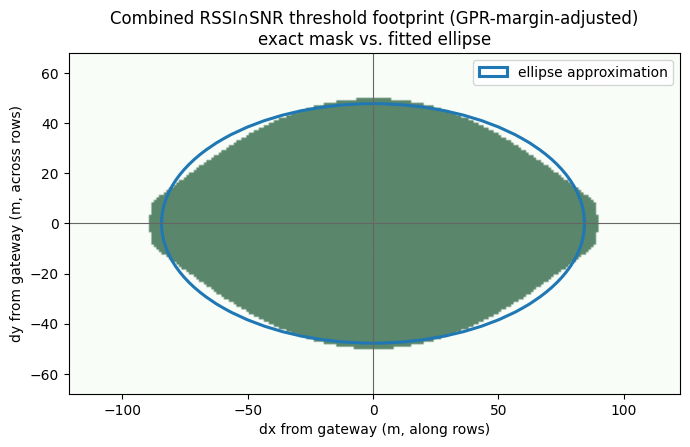

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(combined_mask.astype(float), origin="lower",
          extent=[dx_grid.min(), dx_grid.max(), dy_grid.min(), dy_grid.max()],
          cmap="Greens", alpha=0.65, vmin=0, vmax=1)
ellipse_patch = Ellipse((0, 0), width=2 * ellipse_x_radius_m, height=2 * ellipse_y_radius_m,
                        fill=False, edgecolor="tab:blue", linewidth=2.2,
                        label="ellipse approximation")
ax.add_patch(ellipse_patch)
ax.axhline(0, color="0.4", linewidth=0.8)
ax.axvline(0, color="0.4", linewidth=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("dx from gateway (m, along rows)")
ax.set_ylabel("dy from gateway (m, across rows)")
ax.set_title("Combined RSSI∩SNR threshold footprint (GPR-margin-adjusted)\n"
             "exact mask vs. fitted ellipse")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("ellipse_footprint_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3 Greedy placement over a dense candidate grid ("place anywhere")

Candidates are a dense grid over the whole greenhouse (minus the central
path corridor), so placement is effectively unconstrained. The ellipse
coverage matrix makes each greedy step a cheap boolean union instead of a
GPR predict.

In [8]:
def make_gateway_candidates(x_min, x_max, y_min, y_max, spacing_m, exclude_x_range=None):
    xs = np.arange(x_min, x_max + spacing_m, spacing_m)
    ys = np.arange(y_min, y_max + spacing_m, spacing_m)
    xx, yy = np.meshgrid(xs, ys)
    candidates = pd.DataFrame({"candidate_id": np.arange(xx.size),
                               "x": xx.ravel(), "y": yy.ravel()})
    if exclude_x_range is not None:
        low, high = exclude_x_range
        candidates = candidates[~candidates["x"].between(low, high)].reset_index(drop=True)
    return candidates


def ellipse_coverage_matrix(points_df, candidates_df, x_radius, y_radius):
    px = points_df["x"].to_numpy(float)[None, :]
    py = points_df["y"].to_numpy(float)[None, :]
    gx = candidates_df["x"].to_numpy(float)[:, None]
    gy = candidates_df["y"].to_numpy(float)[:, None]
    normalized = ((px - gx) / x_radius) ** 2 + ((py - gy) / y_radius) ** 2
    return normalized <= 1.0


def greedy_ellipse_optimization(coverage_by_candidate, candidates_df,
                                max_gateways=MAX_GATEWAYS,
                                min_marginal_gain=MIN_MARGINAL_GAIN):
    """Greedy set cover against the fixed ellipse footprint — cheap per
    candidate; final result is re-validated against the real GPR model."""
    covered = np.zeros(coverage_by_candidate.shape[1], dtype=bool)
    available = np.ones(coverage_by_candidate.shape[0], dtype=bool)
    rows, coverage_history = [], []
    previous_fraction = 0.0

    for gateway_number in range(1, max_gateways + 1):
        candidate_indices = np.flatnonzero(available)
        union_fraction = np.logical_or(
            coverage_by_candidate[candidate_indices], covered).mean(axis=1)
        best_local = int(np.argmax(union_fraction))
        best_idx = int(candidate_indices[best_local])
        best_fraction = float(union_fraction[best_local])
        marginal_gain = best_fraction - previous_fraction
        if marginal_gain < min_marginal_gain:
            break

        covered = np.logical_or(covered, coverage_by_candidate[best_idx])
        available[best_idx] = False
        covered_fraction = float(covered.mean())
        chosen = candidates_df.iloc[best_idx]
        rows.append({
            "gateway_number": gateway_number,
            "candidate_id": int(chosen["candidate_id"]),
            "x": float(chosen["x"]), "y": float(chosen["y"]),
            "covered_percent": 100 * covered_fraction,
            "marginal_percent_gain": 100 * (covered_fraction - previous_fraction),
        })
        coverage_history.append(covered.copy())
        previous_fraction = covered_fraction

    return pd.DataFrame(rows), coverage_history


ellipse_candidates_df = make_gateway_candidates(
    X_MIN, X_MAX, Y_MIN, Y_MAX, spacing_m=CANDIDATE_SPACING_M,
    exclude_x_range=(CENTRAL_PATH_X_MIN, CENTRAL_PATH_X_MAX))

ellipse_coverage_by_candidate = ellipse_coverage_matrix(
    search_grid, ellipse_candidates_df, ellipse_x_radius_m, ellipse_y_radius_m)

ellipse_results, ellipse_coverage_history = greedy_ellipse_optimization(
    ellipse_coverage_by_candidate, ellipse_candidates_df)

print(f"Ellipse-footprint greedy placement: {len(ellipse_results)} gateway(s)")
print(ellipse_results)


Ellipse-footprint greedy placement: 8 gateway(s)
   gateway_number  candidate_id     x      y  covered_percent  \
0               1            74 -87.0  -93.6         8.615385   
1               2            85  78.0  -93.6        17.230769   
2               3           235 -87.0   11.4        25.846154   
3               4           246  78.0   11.4        34.461538   
4               5           396 -87.0  116.4        43.076923   
5               6           407  78.0  116.4        51.692308   
6               7           557 -87.0  221.4        60.307692   
7               8           568  78.0  221.4        68.923077   

   marginal_percent_gain  
0               8.615385  
1               8.615385  
2               8.615385  
3               8.615385  
4               8.615385  
5               8.615385  
6               8.615385  
7               8.615385  


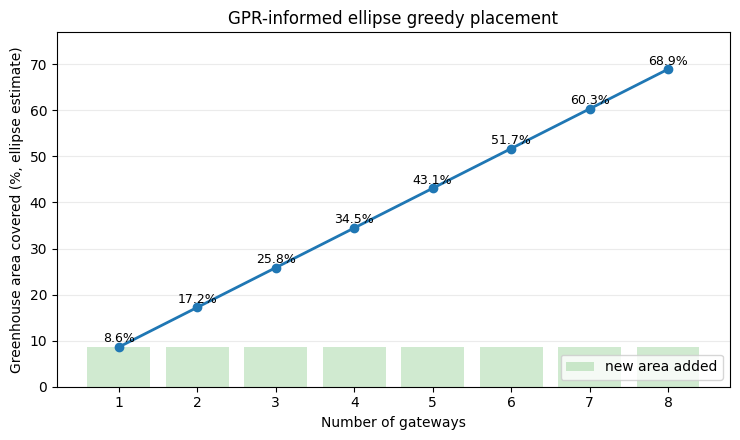

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(ellipse_results["gateway_number"], ellipse_results["covered_percent"],
        marker="o", color="tab:blue", linewidth=2)
ax.bar(ellipse_results["gateway_number"], ellipse_results["marginal_percent_gain"],
       alpha=0.22, color="tab:green", label="new area added")
for _, row in ellipse_results.iterrows():
    ax.text(row["gateway_number"], row["covered_percent"] + 1.0,
            f"{row['covered_percent']:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("Number of gateways")
ax.set_ylabel("Greenhouse area covered (%, ellipse estimate)")
ax.set_title("GPR-informed ellipse greedy placement")
ax.set_xticks(ellipse_results["gateway_number"])
ax.set_ylim(0, min(105, max(10, ellipse_results["covered_percent"].max() + 8)))
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ellipse_gateway_coverage_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4 Validation against the real GPR model

**This is the number that matters.** The ellipse curve above is an
estimate; here the selected positions are checked against the full
two-stage RSSI+SNR model (with the `z` uncertainty margin) on `report_grid`.
If real coverage lands meaningfully below the ellipse estimate, the margin
was too loose — lower `RESIDUAL_QUANTILE` (e.g. 0.05) or raise `Z_MARGIN`
and rerun from section 4.1.

Ellipse estimate (footprint only)          : 68.9% with 8 gateway(s)
REAL achieved coverage (full GPR, z=1.645) : 80.3%


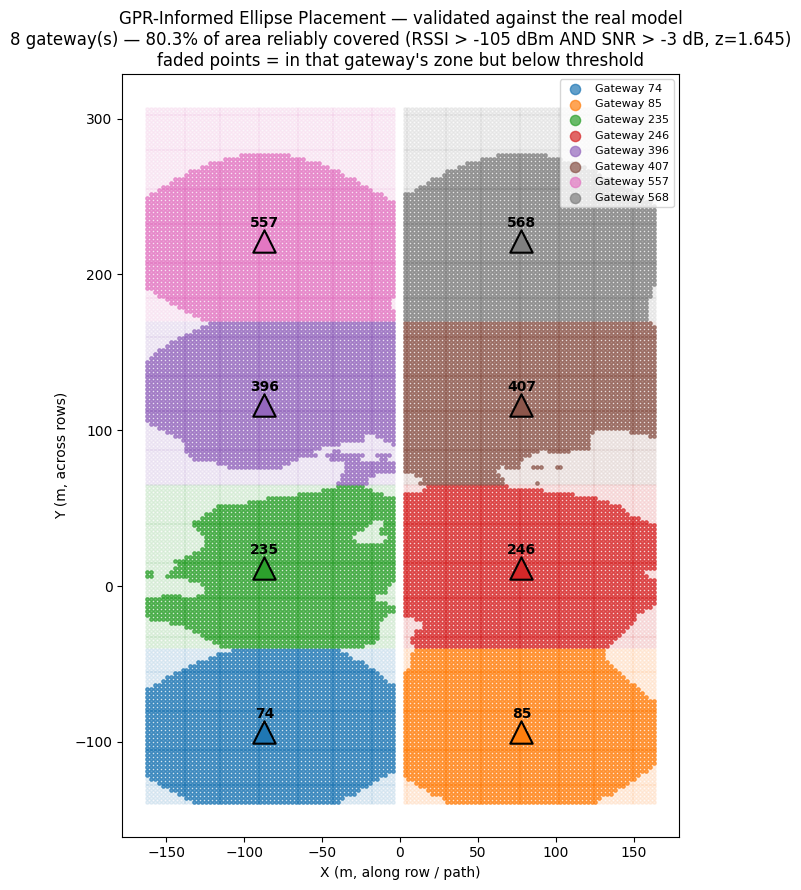


Final placement saved to final_gateway_placement.csv:
   candidate_id     x      y
0            74 -87.0  -93.6
1            85  78.0  -93.6
2           235 -87.0   11.4
3           246  78.0   11.4
4           396 -87.0  116.4
5           407  78.0  116.4
6           557 -87.0  221.4
7           568  78.0  221.4


In [10]:
ellipse_selected_ids = ellipse_results["candidate_id"].tolist()
_, ellipse_real_covered = compute_coverage_assignment(
    ellipse_selected_ids, ellipse_candidates_df, report_grid)

print(f"Ellipse estimate (footprint only)          : "
      f"{ellipse_results['covered_percent'].iloc[-1]:.1f}% "
      f"with {len(ellipse_selected_ids)} gateway(s)")
print(f"REAL achieved coverage (full GPR, z={Z_MARGIN}) : "
      f"{ellipse_real_covered.mean():.1%}")

fig, ax = plot_gateway_coverage(
    ellipse_selected_ids, ellipse_candidates_df, report_grid,
    title="GPR-Informed Ellipse Placement — validated against the real model")
fig.savefig("gateway_coverage_map_final.png", dpi=150, bbox_inches="tight")
plt.show()

# Export final placement for the report / teammates
final_placement = ellipse_candidates_df[
    ellipse_candidates_df["candidate_id"].isin(ellipse_selected_ids)
].reset_index(drop=True)
final_placement.to_csv("final_gateway_placement.csv", index=False)
print("\nFinal placement saved to final_gateway_placement.csv:")
print(final_placement)


## 5. FALLBACK — discrete multi-restart greedy

If you have a fixed list of real, feasible mounting
positions, this section evaluates every candidate against the **full GPR model**
directly (no ellipse), with best-server logic (RSSI winner per point, SNR
travels with it) and multi-restart to catch the case where the best
standalone gateway isn't in the true minimal covering set.

Set `RUN_FALLBACK = True` in section 0 and define `real_candidates_df`
(columns `candidate_id, x, y`) below.

In [11]:
def rank_single_gateways(candidates_df, grid_df,
                         rssi_threshold=RSSI_THRESHOLD_DBM,
                         snr_threshold=SNR_THRESHOLD_DB, z=Z_MARGIN):
    results = []
    for _, row in candidates_df.iterrows():
        rssi_mean, rssi_std, snr_mean, snr_std = predict_rssi_snr_for_gateway(
            row["x"], row["y"], grid_df)
        covered = coverage_mask(rssi_mean, rssi_std, snr_mean, snr_std,
                                rssi_threshold, snr_threshold, z=z)
        results.append(covered.mean())
    out = candidates_df.copy()
    out["coverage_pct"] = results
    return out.sort_values("coverage_pct", ascending=False).reset_index(drop=True)


def greedy_gateway_selection(candidates_df, grid_df,
                             rssi_threshold=RSSI_THRESHOLD_DBM,
                             snr_threshold=SNR_THRESHOLD_DB,
                             max_gateways=MAX_GATEWAYS, min_marginal_gain=0.01,
                             z=Z_MARGIN, forced_first_id=None, cache=None,
                             verbose=True):
    n_points = len(grid_df)
    if cache is None:
        cache = {}
        for _, row in candidates_df.iterrows():
            cache[row["candidate_id"]] = predict_rssi_snr_for_gateway(
                row["x"], row["y"], grid_df)

    best_rssi_mean_so_far = np.full(n_points, -np.inf)
    best_rssi_std_so_far = np.zeros(n_points)
    best_snr_mean_so_far = np.full(n_points, -np.inf)
    best_snr_std_so_far = np.zeros(n_points)
    covered_so_far = np.zeros(n_points, dtype=bool)

    selected = []
    remaining = candidates_df.copy()

    for step in range(max_gateways):
        if step == 0 and forced_first_id is not None:
            candidate_ids = [forced_first_id]
        else:
            candidate_ids = remaining["candidate_id"].tolist()

        best_gain, best_id, best_state = -1, None, None

        for cand_id in candidate_ids:
            rssi_mean, rssi_std, snr_mean, snr_std = cache[cand_id]
            # Best-server switch decided by RSSI only; SNR follows the winner
            switch = rssi_mean > best_rssi_mean_so_far
            t_rssi_mean = np.where(switch, rssi_mean, best_rssi_mean_so_far)
            t_rssi_std = np.where(switch, rssi_std, best_rssi_std_so_far)
            t_snr_mean = np.where(switch, snr_mean, best_snr_mean_so_far)
            t_snr_std = np.where(switch, snr_std, best_snr_std_so_far)

            t_covered = coverage_mask(t_rssi_mean, t_rssi_std, t_snr_mean, t_snr_std,
                                      rssi_threshold, snr_threshold, z=z)
            gain = (t_covered & ~covered_so_far).sum() / n_points

            if gain > best_gain:
                best_gain, best_id = gain, cand_id
                best_state = (t_rssi_mean, t_rssi_std, t_snr_mean, t_snr_std, t_covered)

        if best_id is None or best_gain < min_marginal_gain:
            if verbose:
                print(f"Stopping: marginal gain {best_gain:.3%} below threshold "
                      f"{min_marginal_gain:.3%} (or no candidates left).")
            break

        selected.append(best_id)
        (best_rssi_mean_so_far, best_rssi_std_so_far,
         best_snr_mean_so_far, best_snr_std_so_far, covered_so_far) = best_state
        remaining = remaining[remaining["candidate_id"] != best_id]

        total_coverage = covered_so_far.mean()
        if verbose:
            print(f"Step {step+1}: added gateway {best_id} "
                  f"(+{best_gain:.1%} marginal) -> total coverage {total_coverage:.1%}")
        if total_coverage >= 0.999:
            if verbose:
                print("Reached ~100% coverage.")
            break

    return selected, covered_so_far, (best_rssi_mean_so_far, best_rssi_std_so_far,
                                      best_snr_mean_so_far, best_snr_std_so_far)


def multi_restart_greedy(candidates_df, grid_df,
                         rssi_threshold=RSSI_THRESHOLD_DBM,
                         snr_threshold=SNR_THRESHOLD_DB,
                         n_restarts=5, max_gateways=MAX_GATEWAYS,
                         min_marginal_gain=0.01, z=Z_MARGIN):
    """Greedy once per top-N standalone candidate, each forced as step 1.
    If restarts disagree on gateway count, the unforced greedy answer may
    not be optimal — inspect summary_df or consider an exact ILP solve."""
    cache = {}
    for _, row in candidates_df.iterrows():
        cache[row["candidate_id"]] = predict_rssi_snr_for_gateway(
            row["x"], row["y"], grid_df)

    ranked = rank_single_gateways(candidates_df, grid_df,
                                  rssi_threshold, snr_threshold, z=z)
    start_ids = ranked["candidate_id"].head(n_restarts).tolist()

    summary_rows, full_results = [], {}
    for start_id in start_ids:
        selected, covered, signal = greedy_gateway_selection(
            candidates_df, grid_df, rssi_threshold, snr_threshold,
            max_gateways=max_gateways, min_marginal_gain=min_marginal_gain,
            z=z, forced_first_id=start_id, cache=cache, verbose=False)
        full_results[start_id] = (selected, covered, signal)
        summary_rows.append({
            "start_candidate": start_id,
            "n_gateways_used": len(selected),
            "final_coverage_pct": covered.mean(),
            "selected_order": selected,
        })

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["n_gateways_used", "final_coverage_pct"],
        ascending=[True, False]).reset_index(drop=True)

    best_n = summary_df["n_gateways_used"].min()
    n_agreeing = (summary_df["n_gateways_used"] == best_n).sum()
    print(f"Best restart uses {best_n} gateway(s); "
          f"{n_agreeing}/{len(summary_df)} restarts agree on that count.")
    if n_agreeing < len(summary_df):
        print("Disagreement across restarts — inspect summary_df and prefer the "
              "lowest-n_gateways_used row, or move to an exact ILP solve if the "
              "candidate list is small.")
    return summary_df, full_results


In [ ]:
if RUN_FALLBACK:
    # Replace with the real feasible mounting positions:
    # real_candidates_df = pd.DataFrame({
    #     "candidate_id": [...], "x": [...], "y": [...],
    # })
    if "real_candidates_df" not in globals():
        raise NameError("RUN_FALLBACK=True but real_candidates_df is not defined "
                        "(columns: candidate_id, x, y).")

    fb_summary_df, fb_full_results = multi_restart_greedy(
        real_candidates_df, search_grid)
    best_start = fb_summary_df.iloc[0]["start_candidate"]
    fb_selected, _, _ = fb_full_results[best_start]
    print(f"\n[fallback] best restart ({best_start}) selected "
          f"{len(fb_selected)} of {len(real_candidates_df)} candidates: {fb_selected}")

    _, fb_covered = compute_coverage_assignment(
        fb_selected, real_candidates_df, report_grid)
    print(f"[fallback] real achieved coverage (report grid): {fb_covered.mean():.1%}")

    fig, ax = plot_gateway_coverage(
        fb_selected, real_candidates_df, report_grid,
        title="Fallback: Discrete Multi-Restart Greedy Placement")
    fig.savefig("gateway_coverage_map_fallback.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Fallback disabled (RUN_FALLBACK=False).")


Fallback disabled (RUN_FALLBACK=False).
